In [90]:
import pandas as pd
from joblib import load
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_auc_score
)
import sys
sys.path.insert(0, "../../")
from utils.ploting_figures import MakePlots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

In [91]:
model_original = load('../../models/RandomForest_Grid_42_Original_best.joblib')
model_undersampling = load('../../models/RandomForest_Grid_42_Under_best.joblib')
model_oversampling = load('../../models/RandomForest_Grid_42_Over_best.joblib')

In [92]:
name_data = "ProtT5"
#df_data = pd.read_csv(f"../../data/{name_data}.csv")
df_data= pd.read_csv(f"../../data/numerical_rep/{name_data}.csv")

In [93]:
X_test= df_data.copy()
y_test=X_test['target']
X_test=X_test.drop(columns=['experimental_characteristics', 'half_life_seconds', 'length_sequence', 'target'])

In [94]:
df_data

,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_1019,p_1020,p_1021,p_1022,p_1023,p_1024,target,experimental_characteristics,half_life_seconds,length_sequence
0,0.024928,0.038137,0.010136,0.013962,0.003674,-0.054007,0.023122,0.204115,-0.129186,-0.162114,...,0.060945,0.010294,0.168054,-0.020148,0.067316,-0.133364,1,Mammalian,15840.0,9
1,-0.032362,-0.000383,-0.048013,0.011207,-0.005493,-0.058146,-0.051805,-0.028580,0.028206,-0.030951,...,-0.037678,0.033790,0.201147,0.025814,0.094777,-0.116653,1,Mammalian,15840.0,28
2,0.056347,-0.045785,-0.013331,-0.050032,-0.088194,-0.073964,-0.068582,0.031079,-0.001762,-0.124785,...,0.018659,0.031999,0.077117,-0.017236,0.066621,-0.089538,1,Mammalian,15840.0,9
3,-0.011724,0.112869,-0.010287,-0.013133,-0.023317,-0.039255,-0.106493,0.041725,-0.067948,0.025545,...,0.041634,0.000973,0.049307,0.021370,0.047843,-0.033902,1,Mammalian,15840.0,45
4,-0.105726,0.069741,-0.127632,-0.124845,0.202506,0.030408,-0.049978,0.130994,0.033893,0.089469,...,-0.082009,-0.066162,0.287695,0.050576,0.212813,0.008588,1,Mammalian,15840.0,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308,-0.100075,0.001455,0.017908,0.044346,-0.079563,0.011130,-0.021392,0.009696,0.048142,0.042567,...,-0.029305,0.093444,0.089840,0.031600,0.066225,-0.084514,1,Mammalian,10080.0,20
1309,-0.117940,0.047649,-0.007363,-0.014420,0.019296,0.058130,-0.071593,0.036150,0.075177,-0.137731,...,0.036152,-0.014890,0.138495,-0.086376,0.005198,-0.064887,0,E_coli,7200.0,18
1310,-0.203825,0.062788,0.006884,-0.049276,0.067048,0.083548,-0.154984,0.052247,0.098920,-0.150795,...,0.065029,0.002418,0.121806,-0.107974,-0.035496,-0.073660,1,Mammalian,10080.0,18
1311,-0.203825,0.062788,0.006884,-0.049276,0.067048,0.083548,-0.154984,0.052247,0.098920,-0.150795,...,0.065029,0.002418,0.121806,-0.107974,-0.035496,-0.073660,2,Yeast,36000.0,18


In [95]:
y_pred_original = model_original.predict(X_test)
y_proba_original = model_original.predict_proba(X_test)
y_pred_under = model_undersampling.predict(X_test)
y_proba_under = model_undersampling.predict_proba(X_test)
y_pred_over = model_oversampling.predict(X_test)
y_proba_over = model_oversampling.predict_proba(X_test)

In [96]:
y_pred_original

array([1, 1, 1, ..., 2, 2, 0])

In [97]:
def metrics(predict, y, dataset, div, predict_proba=None):
    acc_value = accuracy_score(y_pred=predict, y_true=y) 
    recall_value = recall_score(y_pred=predict, y_true=y, average='weighted')
    precision_value = precision_score(y_pred=predict, y_true=y, average='weighted') 
    f1_value = f1_score(y_pred=predict, y_true=y, average='weighted')
    mcc_value = matthews_corrcoef(y_pred=predict, y_true=y)
    cm = confusion_matrix(y_pred=predict, y_true=y)
    cm_dict = pd.DataFrame(cm).to_dict()

    roc_auc_value = None
    if predict_proba is not None:
        try:
            roc_auc_value = roc_auc_score(y, predict_proba, multi_class='ovr', average='weighted')
        except Exception as e:
            print(f"Error computing ROC AUC: {e}")
            roc_auc_value = None

    df_metrics = pd.DataFrame([[dataset, "Random_Forest", div, acc_value, recall_value, precision_value, f1_value, mcc_value, roc_auc_value, cm_dict]],
                              columns=["dataset", "model", "sampling", "acc", "recall", "precision", "f1", "mcc", "roc_auc", "conf_matrix"])

    return df_metrics

In [98]:
original_metrics= metrics(y_pred_original, y_test, 'Test','Original', predict_proba=y_proba_original)
undesampling_metrics = metrics(y_pred_under, y_test, 'Test','Undersampling', predict_proba=y_proba_under)
oversampling_metrics = metrics(y_pred_over, y_test, 'Test','Oversampling', predict_proba=y_proba_over)

In [99]:
df= pd.concat([undesampling_metrics, oversampling_metrics, original_metrics], ignore_index=True)

In [ ]:
df2=

,dataset,model,sampling,acc,recall,precision,f1,mcc,roc_auc,conf_matrix
0,Test,Random_Forest,Undersampling,0.525514,0.525514,0.595768,0.530348,0.311335,0.714273,"{0: {0: 317, 1: 110, 2: 6}, 1: {0: 191, 1: 202..."
1,Test,Random_Forest,Oversampling,0.669459,0.669459,0.681688,0.670902,0.470292,0.819202,"{0: {0: 483, 1: 125, 2: 15}, 1: {0: 130, 1: 24..."
2,Test,Random_Forest,Original,0.663366,0.663366,0.658029,0.651055,0.418893,0.812924,"{0: {0: 568, 1: 198, 2: 69}, 1: {0: 91, 1: 209..."


In [101]:
conf_matrix = df[["sampling", "conf_matrix"]]
conf_matrix

,sampling,conf_matrix
0,Undersampling,"{0: {0: 317, 1: 110, 2: 6}, 1: {0: 191, 1: 202..."
1,Oversampling,"{0: {0: 483, 1: 125, 2: 15}, 1: {0: 130, 1: 24..."
2,Original,"{0: {0: 568, 1: 198, 2: 69}, 1: {0: 91, 1: 209..."


In [102]:
df.rename(columns={
    "acc": "Accuracy",
    "recall": "Recall",
    "precision": "Precision",
    "f1": "F1-score",
    "mcc": "MCC",
    "model": "Algorithm",
    "dataset": "Stage",
    "roc_auc": "ROC-AUC"
}, inplace=True)

In [103]:
df

,Stage,Algorithm,sampling,Accuracy,Recall,Precision,F1-score,MCC,ROC-AUC,conf_matrix
0,Test,Random_Forest,Undersampling,0.525514,0.525514,0.595768,0.530348,0.311335,0.714273,"{0: {0: 317, 1: 110, 2: 6}, 1: {0: 191, 1: 202..."
1,Test,Random_Forest,Oversampling,0.669459,0.669459,0.681688,0.670902,0.470292,0.819202,"{0: {0: 483, 1: 125, 2: 15}, 1: {0: 130, 1: 24..."
2,Test,Random_Forest,Original,0.663366,0.663366,0.658029,0.651055,0.418893,0.812924,"{0: {0: 568, 1: 198, 2: 69}, 1: {0: 91, 1: 209..."


In [104]:
palette_values = ['#026E81', '#00ABBD', '#101D42', '#F45F74']
palette_values2=['#00ABBD', '#FFB255', '#F45F74']
colors = sns.color_palette(palette_values)
colors2 = sns.color_palette(palette_values2)

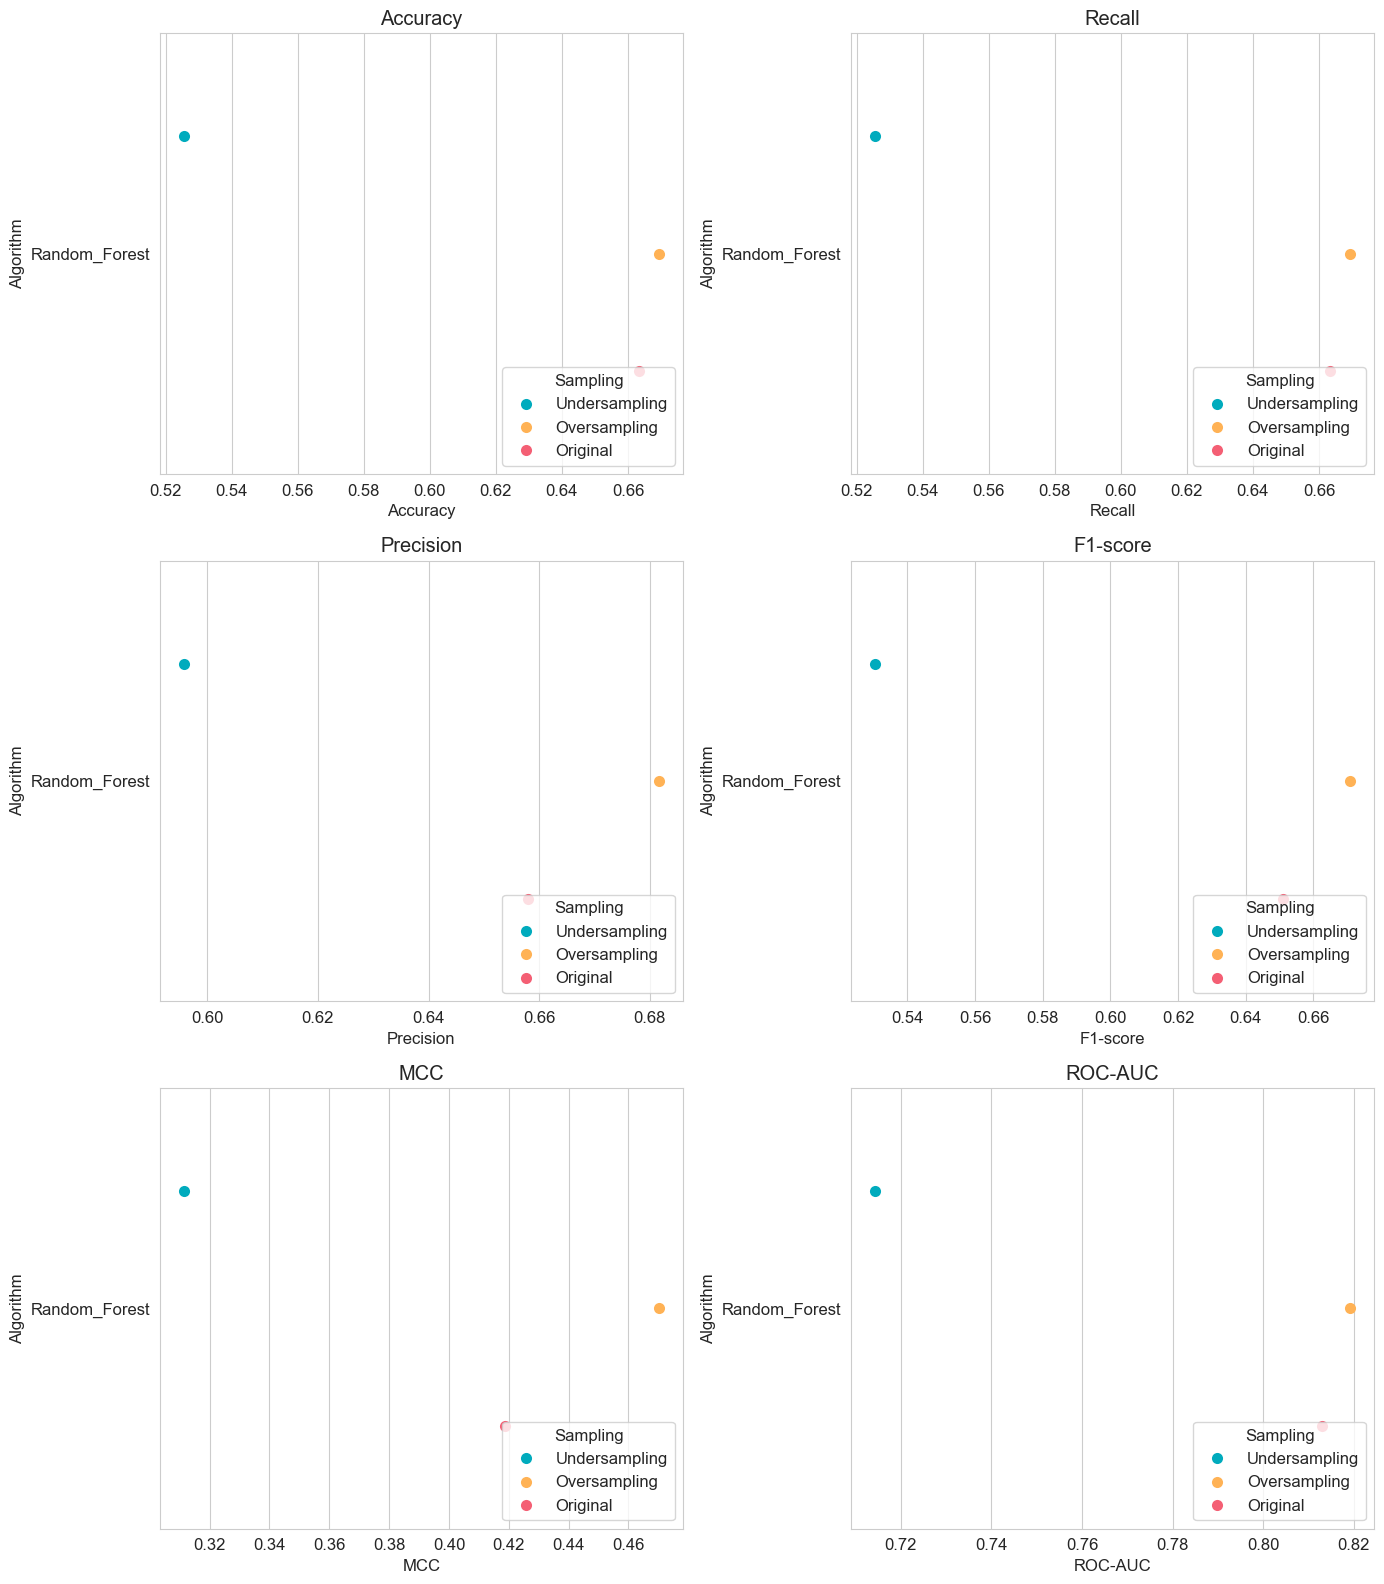

In [105]:
# Lista de métricas que quieres graficar
metrics = ["Accuracy", "Recall", "Precision", "F1-score", "MCC", "ROC-AUC"]

# Graficar
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.stripplot(
        data=df,
        x=metric,
        y="Algorithm",
        hue="sampling",
        palette=colors2,
        dodge=True,
        jitter=0.25,
        size=8,
        ax=ax
    )
    ax.set_title(metric)
    ax.legend(title="Sampling", loc="lower right")

plt.tight_layout()
plt.show()

In [106]:
df_melt = df.melt(id_vars=["Algorithm", "sampling"], 
                  value_vars=["Accuracy", "Recall", "Precision", "F1-score", "MCC", "ROC-AUC"],
                  var_name="Metric", value_name="Score")

# Lista de métricas únicas
metrics_unique = df_melt["Metric"].unique()

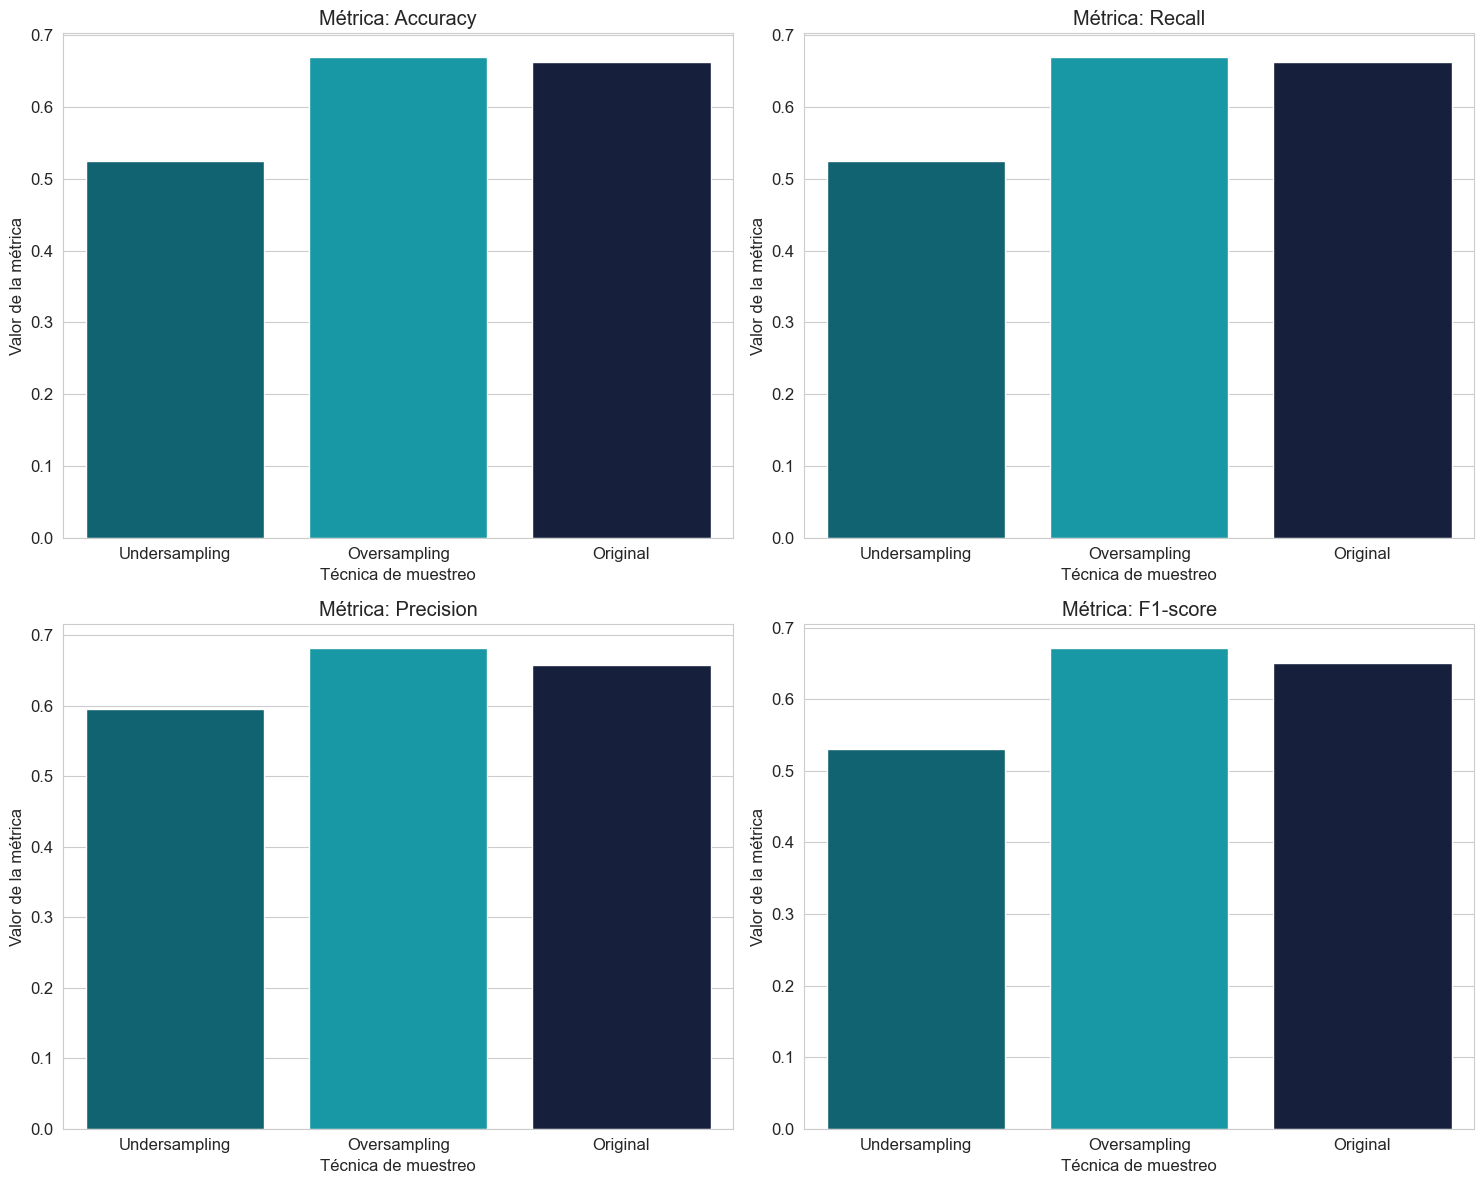

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_unique[:4]):  # 4 métricas para 2x2
    df_metric = df_melt[df_melt["Metric"] == metric]
    sns.barplot(data=df_metric, x="sampling", y="Score", palette=colors, ax=ax)
    ax.set_title(f"Métrica: {metric}")
    ax.set_ylabel("Valor de la métrica")
    ax.set_xlabel("Técnica de muestreo")

plt.tight_layout()
plt.savefig("../../img/RandomForest_Regression_all_metrics.png", dpi=300)
plt.show()

In [108]:
X_test

,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_1015,p_1016,p_1017,p_1018,p_1019,p_1020,p_1021,p_1022,p_1023,p_1024
0,0.024928,0.038137,0.010136,0.013962,0.003674,-0.054007,0.023122,0.204115,-0.129186,-0.162114,...,-0.008170,-0.120455,0.058737,0.107394,0.060945,0.010294,0.168054,-0.020148,0.067316,-0.133364
1,-0.032362,-0.000383,-0.048013,0.011207,-0.005493,-0.058146,-0.051805,-0.028580,0.028206,-0.030951,...,-0.040426,-0.084771,0.062330,-0.006251,-0.037678,0.033790,0.201147,0.025814,0.094777,-0.116653
2,0.056347,-0.045785,-0.013331,-0.050032,-0.088194,-0.073964,-0.068582,0.031079,-0.001762,-0.124785,...,-0.011258,-0.031063,0.087633,0.120435,0.018659,0.031999,0.077117,-0.017236,0.066621,-0.089538
3,-0.011724,0.112869,-0.010287,-0.013133,-0.023317,-0.039255,-0.106493,0.041725,-0.067948,0.025545,...,-0.062280,0.070505,0.051101,0.074827,0.041634,0.000973,0.049307,0.021370,0.047843,-0.033902
4,-0.105726,0.069741,-0.127632,-0.124845,0.202506,0.030408,-0.049978,0.130994,0.033893,0.089469,...,0.059391,-0.020812,-0.006855,0.066739,-0.082009,-0.066162,0.287695,0.050576,0.212813,0.008588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308,-0.100075,0.001455,0.017908,0.044346,-0.079563,0.011130,-0.021392,0.009696,0.048142,0.042567,...,-0.039935,-0.104691,0.052998,0.100753,-0.029305,0.093444,0.089840,0.031600,0.066225,-0.084514
1309,-0.117940,0.047649,-0.007363,-0.014420,0.019296,0.058130,-0.071593,0.036150,0.075177,-0.137731,...,-0.045621,-0.056583,0.050460,0.018345,0.036152,-0.014890,0.138495,-0.086376,0.005198,-0.064887
1310,-0.203825,0.062788,0.006884,-0.049276,0.067048,0.083548,-0.154984,0.052247,0.098920,-0.150795,...,-0.074419,-0.048853,-0.012628,0.023684,0.065029,0.002418,0.121806,-0.107974,-0.035496,-0.073660
1311,-0.203825,0.062788,0.006884,-0.049276,0.067048,0.083548,-0.154984,0.052247,0.098920,-0.150795,...,-0.074419,-0.048853,-0.012628,0.023684,0.065029,0.002418,0.121806,-0.107974,-0.035496,-0.073660


In [109]:
y_test

0       1
1       1
2       1
3       1
4       1
       ..
1308    1
1309    0
1310    1
1311    2
1312    0
Name: target, Length: 1313, dtype: int64

In [110]:
palette_values = ['#00B0BE', '#F45F74', '#98C127']
colors = sns.color_palette(palette_values)

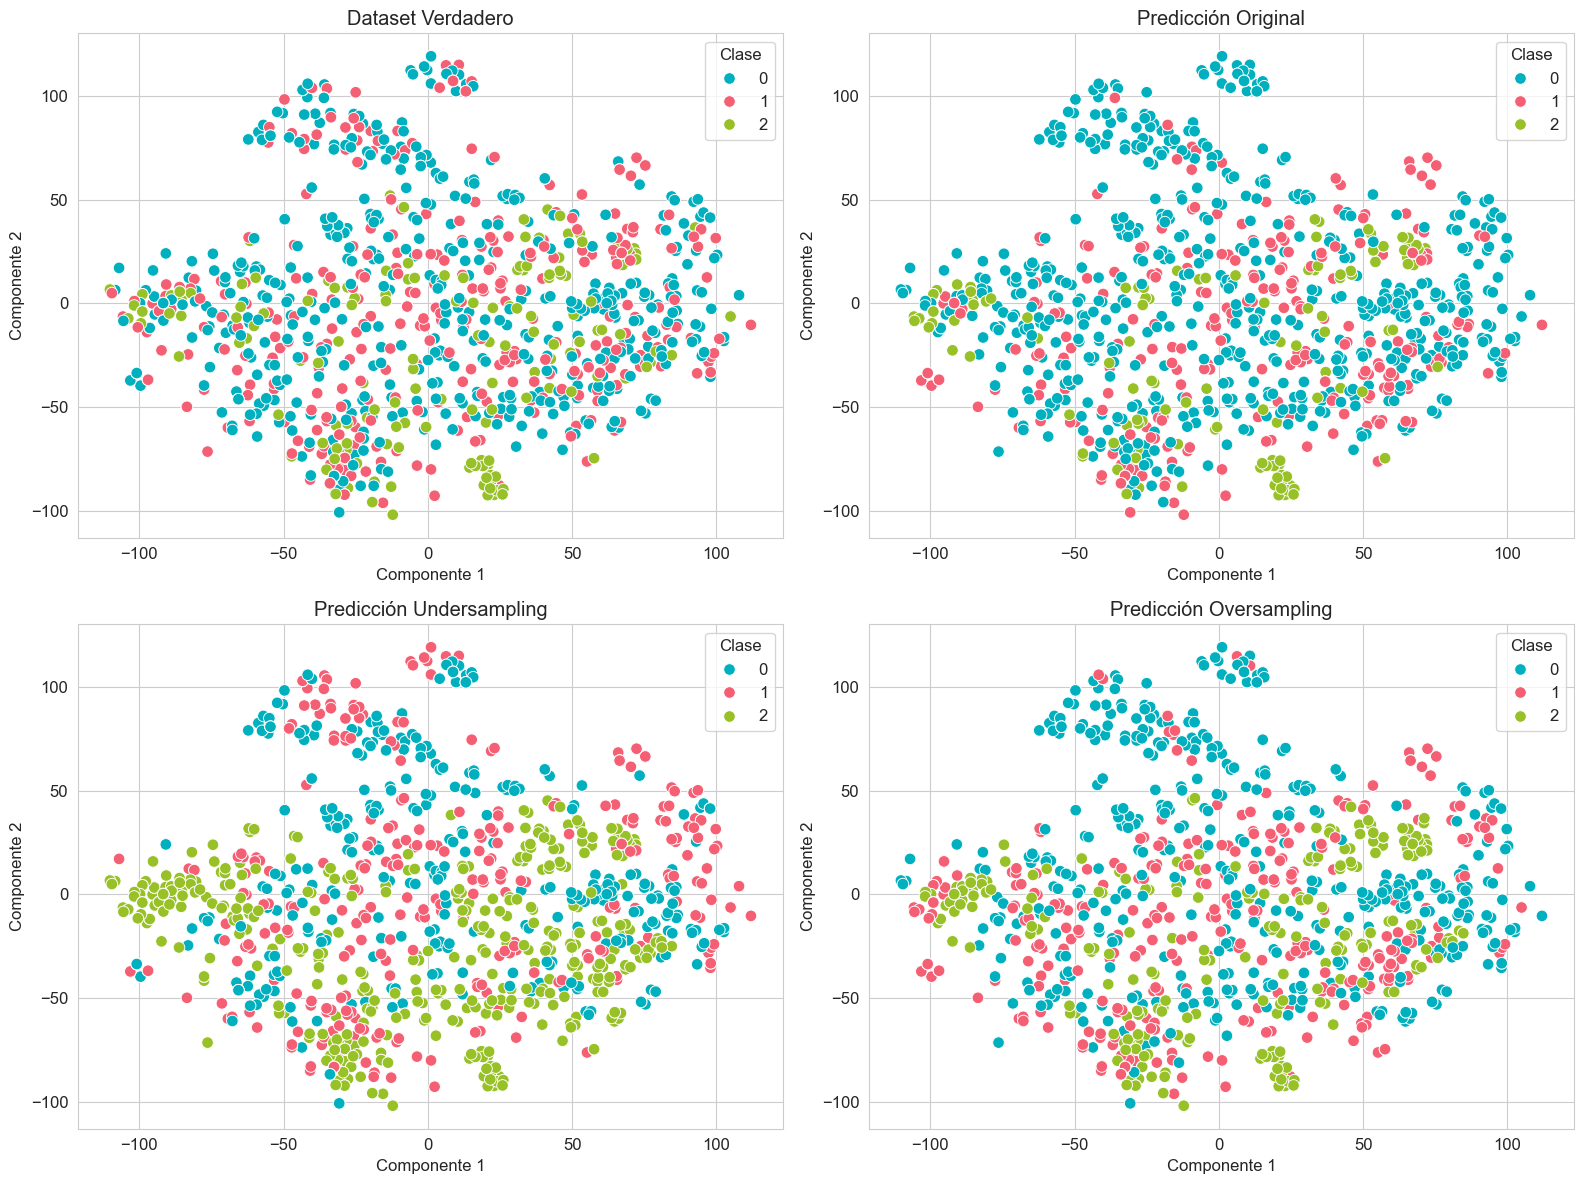

In [113]:
tsne = TSNE(n_components=2, random_state=42).fit_transform(X_test)
df_plot_base = pd.DataFrame(tsne, columns=["TSNE1", "TSNE2"])

# Paso 2: Preparar etiquetas a comparar
etiquetas = {
    "Dataset Verdadero": y_test,
    "Predicción Original": y_pred_original,
    "Predicción Undersampling": y_pred_under,
    "Predicción Oversampling": y_pred_over
}

# Paso 3: Crear subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (titulo, etiquetas_clase) in zip(axes, etiquetas.items()):
    df_plot = df_plot_base.copy()
    df_plot["Clase"] = etiquetas_clase
    sns.scatterplot(data=df_plot, x="TSNE1", y="TSNE2", hue="Clase", palette=colors, s=70, ax=ax)
    ax.set_title(f"{titulo}")
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    ax.legend(title="Clase", loc='best')

plt.tight_layout()
plt.savefig("../../img/tsne_comparacion_modelos.png", dpi=300)
plt.show()